In [ ]:
#download libraries

In [5]:
%pip install numpy
%pip install torch-directml
!python -m ipykernel install --user --name pydml --display-name "Python (PyTorch DirectML)"
%pip install matlabengine==25.1.2 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Installed kernelspec pydml in C:\Users\13523\AppData\Roaming\jupyter\kernels\pydml
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Import libraries

In [16]:
from tqdm.auto import tqdm
import numpy as np, math
import torch, torch_directml
import matlab.engine
import os
import matplotlib.pyplot as plt

In [17]:
#Verify GPU acceleration

In [18]:
dml = torch_directml.device()
print("DML device object:", dml)
#pos_pf_t = torch.tensor(pos_pf, device=dml)


DML device object: privateuseone:0


In [19]:
#Sanity test for actual GPU acceleration

In [5]:
# 2) simple ops ON the GPU
x = torch.randn(4096, 4096).to(dml)   # move tensor to DML
y = x @ x.T                           # runs on GPU
print("y.device:", y.device)          # expect device(type='privateuseone', index=0)

# 3) quick timing vs CPU (sanity)
import time
# warmup
_ = x @ x.T

t0 = time.time()
for _ in range(5):
    _ = x @ x.T
print("DML 5x matmul:", round(time.time()-t0, 2), "s")

x_cpu = torch.randn(4096, 4096)
t0 = time.time()
for _ in range(5):
    _ = x_cpu @ x_cpu.T
print("CPU 5x matmul:", round(time.time()-t0, 2), "s")

y.device: privateuseone:0
DML 5x matmul: 0.09 s
CPU 5x matmul: 2.36 s


In [ ]:
#Check vram bytes for local gpu (implemented for AMD)

In [31]:
import subprocess, json

def get_vram_from_powershell():
    cmd = [
        "powershell", "-NoProfile", "-Command",
        "Get-CimInstance Win32_VideoController | "
        "Select-Object Name,AdapterRAM | ConvertTo-Json -Depth 3"
    ]
    out = subprocess.check_output(cmd, text=True)
    data = json.loads(out)
    if isinstance(data, dict): data = [data]
    data = [d for d in data if 'AdapterRAM' in d and isinstance(d['AdapterRAM'], int)]
    if not data:
        return None
    best = max(data, key=lambda d: d['AdapterRAM'])
    return best["Name"], best["AdapterRAM"]

info = get_vram_from_powershell()
if info:
    name, ram = info
    print(f"GPU: {name}\nVRAM: {ram/1024**3:.2f} GiB ({ram} bytes)")
else:
    print("Couldn’t query VRAM via PowerShell.")


GPU: AMD Radeon 780M Graphics
VRAM: 0.50 GiB (536870912 bytes)


In [6]:
#Read matlab variables and save to nunmpy ararys

In [47]:
# === Config ===
matfile = r"YZ_2D_20250813_211229.mat"   # your file
matpath = os.path.abspath(matfile).replace("\\", "/")

# === Start MATLAB engine ===
eng = matlab.engine.start_matlab("-nojvm")

# === Load .mat into struct S ===
eng.eval(f"S = load('{matpath}');", nargout=0)

# === Push variables from struct S into MATLAB base workspace ===
eng.eval("""
recs           = S.recs;
xgrid          = S.xgrid;
ygrid          = S.ygrid;
zgrid          = S.zgrid;
freq           = S.freq;
TxRxPairs      = S.TxRxPairs;
printer_offsets = S.printer_offsets;
NxN            = S.NxN;
xstep          = S.xstep;
zstep          = S.zstep;
gridCenter     = S.gridCenter;
""", nargout=0)

# === Pull into Python ===
recs            = np.array(eng.workspace["recs"])
xgrid           = np.array(eng.workspace["xgrid"]).reshape(-1).astype(np.float32)  # should be length 60 (or 1 if X is collapsed)
ygrid           = np.array(eng.workspace["ygrid"]).reshape(-1).astype(np.float32)  # expect 60
zgrid           = np.array(eng.workspace["zgrid"]).reshape(-1).astype(np.float32)  # expect 60
freq            = np.array(eng.workspace["freq"]).squeeze().astype(np.float32)  # -> shape (60,)
TxRxPairs       = np.array(eng.workspace["TxRxPairs"])
printer_offsets = np.array(eng.workspace["printer_offsets"])
NxN             = int(eng.workspace["NxN"])
xstep           = int(eng.workspace["xstep"])
zstep           = int(eng.workspace["zstep"])
gridCenter      = np.array(eng.workspace["gridCenter"])

print("Shapes:")
print("recs:", recs.shape)
print("xgrid:", xgrid.shape); print("ygrid:", ygrid.shape); print("zgrid:", zgrid.shape)
print("freq:", freq.shape)
print("xstep:", xstep, "zstep:", zstep)

Shapes:
recs: (400, 100, 25)
xgrid: (1,)
ygrid: (60,)
zgrid: (60,)
freq: (100,)
xstep: 40 zstep: 40


In [77]:
# ---------------------------- Antenna Locations and Printer Offsets

In [48]:
# --- your antenna table is [Y, X, Z] in meters
Vant_yxz = np.array([
  [-0.0275,-0.0267,0],[-0.0253,-0.0267,0],[-0.0231,-0.0267,0],[-0.0209,-0.0267,0],
  [-0.0187,-0.0267,0],[-0.0165,-0.0267,0],[-0.0143,-0.0267,0],[-0.0122,-0.0267,0],
  [-0.01,-0.0267,0],[-0.0078,-0.0267,0],[-0.0056,-0.0267,0],[-0.0034,-0.0267,0],
  [-0.0012,-0.0267,0],[0.0009,-0.0267,0],[0.0031,-0.0267,0],[0.0053,-0.0267,0],
  [0.0075,-0.0267,0],[0.0097,-0.0267,0],[0.0119,-0.0267,0],[0.0141,-0.0267,0],
  [0.0274,-0.0133,0],[0.0274,-0.0112,0],[0.0274,-0.0091,0],[0.0274,-0.007,0],
  [0.0274,-0.0049,0],[0.0274,-0.0028,0],[0.0274,-0.0007,0],[0.0275,0.0014,0],
  [0.0275,0.0035,0],[0.0275,0.0056,0],[0.0275,0.0078,0],[0.0275,0.0099,0],
  [0.0275,0.012,0],[0.0274,0.0141,0],[0.0274,0.0162,0],[0.0275,0.0183,0],
  [0.0275,0.0204,0],[0.0275,0.0225,0],[0.0275,0.0246,0],[0.0275,0.0267,0]
], dtype=np.float32)

# convert to [X, Y, Z] for the math
Vant_xyz = Vant_yxz[:, [1, 0, 2]]  # swap Y<->X

# your printer_offsets are [Y, X] in mm in the MATLAB code
# convert to [X, Y] in meters for the GPU code
printer_offsets_xy_m = np.column_stack([
    printer_offsets[:, 1],   # X (from your col 2)
    printer_offsets[:, 0],   # Y (from your col 1)
]).astype(np.float32) / 1000.0


In [21]:
# ------------------------------------ Radiation Pattern, Removal of Resonant Frequencies, and Backprojection definition

In [49]:
import numpy as np, torch, time, math, torch_directml
from tqdm import tqdm
dml = torch_directml.device()

def radiation_pattern(theta, phi):
    # F = sqrt(cos(theta/2)^2 * (sin(phi)^2 + (cos(theta)*cos(phi))^2))
    ct = torch.cos(theta)
    term = torch.sin(phi)**2 + (ct*torch.cos(phi))**2
    return torch.sqrt(torch.cos(theta/2)**2 * term + 1e-12)

def remove_resonances_np(X_pf, freq, thresh_db=3.0):
    freq = np.asarray(freq).ravel()
    F = X_pf.shape[1]
    if F < 2 or freq.size < 2:  # not enough to build the kernel
        return X_pf, np.zeros(F, bool)
    df = float(freq[1] - freq[0])
    lnconv = min(
        max(int(np.floor(F/8))*2+1, int(np.floor(50/df))*2+1),
        int(np.floor(3*F/8))*2+1
    )
    c2 = -np.ones(lnconv, np.float32)/(lnconv-1)
    c2[(lnconv-1)//2] = 1.0
    trace_db = 20*np.log10(np.sqrt(np.sum(np.abs(X_pf)**2, axis=0)) + 1e-12)  # [F]
    k = (lnconv-1)//2
    contrast = np.convolve(np.pad(trace_db, (k,k), mode='symmetric'), c2, mode='valid')
    mask = contrast > float(thresh_db)
    return X_pf * (1.0 - mask[None,:].astype(np.float32)), mask


In [81]:
# ------------------------ Backprojection

In [58]:
class BP_GPU:
    def __init__(self, xgrid, ygrid, zgrid, freq, TxRxPairs0, Vant_xyz,
                 RCS=1.0, gain_db=5.8, vox_chunk=8000, freq_tile=16, pair_chunk=64, use_fp16=False,offset_mode="xy"):
        self.dtype = torch.float16 if use_fp16 else torch.float32
        self.c = 299_792_458.0
        self.offset_mode = offset_mode   # options: "xy", "xz", "yz"  (default = xy)

        # axes & voxels on CPU (NO GPU allocations here)
        def _to_1d_cpu(a):
            return torch.as_tensor(np.atleast_1d(a).astype(np.float32), dtype=torch.float32, device="cpu").view(-1)
        self.xc = _to_1d_cpu(xgrid)
        self.yc = _to_1d_cpu(ygrid)
        self.zc = _to_1d_cpu(zgrid)

        Xg, Yg, Zg = torch.meshgrid(self.xc, self.yc, self.zc, indexing='xy')
        self.vox_cpu = torch.stack([Xg, Yg, Zg], dim=-1).reshape(-1, 3)     # [V,3] CPU
        self.V = int(self.vox_cpu.shape[0])
        self.vol_shape = (self.yc.numel(), self.xc.numel(), self.zc.numel()) # [Ny,Nx,Nz]

        # physics constants kept on CPU; moved to DML by tiles
        self.freq_cpu = np.asarray(freq, np.float32).ravel()                 # [F]
        self.k_cpu    = (2*np.pi*self.freq_cpu / self.c).astype(np.float32)  # [F]
        lam_cpu       = (self.c / self.freq_cpu).astype(np.float32)
        self.csf_cpu  = (np.sqrt(RCS) * lam_cpu / ((4*np.pi)**1.5)).astype(np.float32)
        self.g_lin    = float(10.0**(gain_db/20.0))

        # pairs & antennas on CPU
        self.tx_idx_cpu = np.asarray(TxRxPairs0[:,0], np.int64)
        self.rx_idx_cpu = np.asarray(TxRxPairs0[:,1], np.int64)
        self.Vant_cpu   = torch.as_tensor(Vant_xyz.astype(np.float32), device="cpu")

        # tiling
        self.vox_chunk  = int(vox_chunk)
        self.freq_tile  = int(freq_tile)
        self.pair_chunk = int(pair_chunk)

        # validity check (catches your “index 40 out of bounds” immediately)
        Nant = self.Vant_cpu.shape[0]
        i_min = int(min(self.tx_idx_cpu.min(), self.rx_idx_cpu.min()))
        i_max = int(max(self.tx_idx_cpu.max(), self.rx_idx_cpu.max()))
        assert i_min >= 0 and i_max < Nant, \
            f"Tx/Rx out of range after 0-based conv: min={i_min}, max={i_max}, Nant={Nant}"

    def _dynamic_slice(self, vol, thresh=10):
        Nx, Ny, Nz = self.xc.numel(), self.yc.numel(), self.zc.numel()
        if Nx <= thresh:     # YZ plane
            return vol[:,0,:], 'YZ', self.yc.numpy(), self.zc.numpy()
        elif Ny <= thresh:   # XZ plane
            return vol[0,:,:], 'XZ', self.xc.numpy(), self.zc.numpy()
        else:                # XY plane
            return vol[:,:,0], 'XY', self.xc.numpy(), self.yc.numpy()

    def reconstruct(self, recs_pairs_f_recs, printer_offsets_xy_m, remove_res=True):
        # --- shapes ---
        Pairs, F, Nrecs = recs_pairs_f_recs.shape
        Ny, Nx, Nz      = self.vol_shape
    
        # --- dtypes (define BEFORE you use them) ---
        geom_dtype = torch.float32   # v, Apos, d, angles, RP, Smag
        math_dtype = torch.float32   # Sr/Si, cos/sin, denom, accumulators
    
        # --- sanitize input (your print showed NaNs) ---
        X_np = np.nan_to_num(recs_pairs_f_recs, nan=0.0, posinf=0.0, neginf=0.0).astype(np.complex64)
    
        # --- tiling (unchanged) ---
        p_st = list(range(0, Pairs, self.pair_chunk))
        p_en = p_st[1:] + [Pairs]
    
        # --- allocate outputs on DML ---
        y_stack = torch.zeros((Ny, Nx, Nrecs), dtype=math_dtype, device=dml)
        y_sum   = torch.zeros((Ny, Nx),       dtype=math_dtype, device=dml)
    
        # --- constants on device in FP32 ---
        k_cpu   = self.k_cpu        # 1-D numpy float32 you precomputed in __init__
        csf_cpu = self.csf_cpu
        Vant0   = self.Vant_cpu.to(dml, dtype=geom_dtype)
    
        for i in range(Nrecs):
            # per-record: optional resonance removal
            X_pf = X_np[:, :, i]                      # [Pairs, F]
            if remove_res and F > 1:
                X_pf = remove_resonances_np(X_pf, k_cpu * (self.c/(2*np.pi)), thresh_db=3.0)  # or self.freq_cpu
    
            # split to CPU float32 once
            S_r_cpu = torch.from_numpy(X_pf.real.astype('float32'))  # [Pairs, F] CPU
            S_i_cpu = torch.from_numpy(X_pf.imag.astype('float32'))
    
            # offsets -> Apos (FP32)
            yoff = float(printer_offsets_xy_m[i, 0])
            xoff = float(printer_offsets_xy_m[i, 1])
            mode = getattr(self, "offset_mode", "xy").lower()
            if mode == "yx":
                off = torch.tensor([xoff, yoff, 0.0], device=dml, dtype=geom_dtype)
            elif mode == "xy":
                off = torch.tensor([yoff, xoff, 0.0], device=dml, dtype=geom_dtype)
            elif mode == "xz":
                off = torch.tensor([yoff, 0.0, xoff], device=dml, dtype=geom_dtype)
            elif mode == "yz":
                off = torch.tensor([0.0, yoff, xoff], device=dml, dtype=geom_dtype)
            else:
                raise ValueError(f"Unknown offset_mode: {mode}")
    
            Apos = Vant0 + off
    
            # -------- voxel loop (FP32 geometry; math in FP32) --------
            out_r = torch.zeros(self.V, dtype=math_dtype, device=dml)
            out_i = torch.zeros_like(out_r)
    
            for s in range(0, self.V, self.vox_chunk):
                e = min(s + self.vox_chunk, self.V)
                v = self.vox_cpu[s:e].to(dml, dtype=geom_dtype)  # [B,3]
                B = v.size(0)
    
                dv    = v[:, None, :] - Apos[None, :, :]
                d     = torch.linalg.norm(dv, dim=-1).clamp_min(1e-6)   # [B,Nant]
                rho   = torch.linalg.norm(dv[..., :2], dim=-1)
                theta = torch.atan2(rho, dv[..., 2])
                phi   = torch.atan2(dv[..., 1], dv[..., 0])
                RP    = radiation_pattern(theta, phi).to(geom_dtype)
                Smag  = (self.g_lin * RP) / d                           # [B,Nant]
    
                real = torch.zeros(B, dtype=math_dtype, device=dml)
                imag = torch.zeros_like(real)
    
                for ps, pe in zip(p_st, p_en):
                    tx = torch.as_tensor(self.tx_idx_cpu[ps:pe], device=dml)
                    rx = torch.as_tensor(self.rx_idx_cpu[ps:pe], device=dml)
                    Smag_tx = Smag[:, tx]               # [B,Pc]
                    Smag_rx = Smag[:, rx]
                    Rsum    = d[:, tx] + d[:, rx]       # [B,Pc]
    
                    if F == 1:
                        k_t   = torch.tensor(k_cpu[0],   device=dml, dtype=math_dtype)
                        csf_t = torch.tensor(csf_cpu[0], device=dml, dtype=math_dtype)
                        Sr = S_r_cpu[ps:pe, 0].to(dml, dtype=math_dtype)[None, :]
                        Si = S_i_cpu[ps:pe, 0].to(dml, dtype=math_dtype)[None, :]
                        phase = Rsum * k_t
                        cp, sp = torch.cos(phase), torch.sin(phase)
                        denom  = csf_t * Smag_tx * Smag_rx + 1e-12
                        Pr = (Sr*cp - Si*sp) / denom
                        Pi = (Sr*sp + Si*cp) / denom
                        real += Pr.sum(dim=1)
                        imag += Pi.sum(dim=1)
                    else:
                        for f0 in range(0, F, self.freq_tile):
                            f1   = min(f0 + self.freq_tile, F)
                            k_t  = torch.tensor(k_cpu[f0:f1],   device=dml, dtype=math_dtype)
                            csf_t= torch.tensor(csf_cpu[f0:f1], device=dml, dtype=math_dtype)
                            Sr = S_r_cpu[ps:pe, f0:f1].to(dml, dtype=math_dtype)[None, ...]
                            Si = S_i_cpu[ps:pe, f0:f1].to(dml, dtype=math_dtype)[None, ...]
                            phase = Rsum[..., None] * k_t[None, None, :]
                            cp, sp = torch.cos(phase), torch.sin(phase)
                            denom  = csf_t[None,None,:] * Smag_tx[...,None] * Smag_rx[...,None] + 1e-12
                            Pr = (Sr*cp - Si*sp) / denom
                            Pi = (Sr*sp + Si*cp) / denom
                            real += Pr.sum(dim=(1,2))
                            imag += Pi.sum(dim=(1,2))
                            del cp, sp, denom, Pr, Pi, Sr, Si  # free per tile
    
                out = torch.sqrt(real*real + imag*imag)
                out_r[s:e] = real.to(out_r.dtype)
                out_i[s:e] = imag.to(out_i.dtype)
    
            vol = torch.sqrt(out_r.float()*out_r.float() + out_i.float()*out_i.float()) \
                    .reshape(self.x_cpu.numel(), self.y_cpu.numel(), self.z_cpu.numel()) \
                    .permute(1,0,2)  # [Ny,Nx,Nz]
    
            img, sliceName, rows, cols = self._dynamic_slice(vol, thresh=10)
            y_stack[:,:,i] = img
            y_sum += img
    
        meta = {"sliceName": sliceName, "rows": np.array(rows), "cols": np.array(cols)}
        return y_stack.cpu().numpy().astype('float32'), y_sum.cpu().numpy().astype('float32'), meta


In [24]:
bp.offset_mode = "yx"

NameError: name 'bp' is not defined

In [59]:
# from MATLAB:
# recs: [Pairs,F,Nrecs] complex64
# freq: (F,)
# TxRxPairs: [Pairs,2] 1-based (MATLAB)
# Vant_yxz: [Nant,3]  (Y,X,Z) meters
# printer_offsets: [Nrecs,2] (Y,X) mm
# xgrid,ygrid,zgrid: scalar or 1D (meters)

# conversions
TxRxPairs0 = TxRxPairs.astype(np.int64) - 1
Vant_xyz   = Vant_yxz[:, [1,0,2]].astype(np.float32)
printer_offsets_xy_m = np.column_stack([printer_offsets[:,1], printer_offsets[:,0]]).astype(np.float32)/1000.0

# **verify pairs in range** (this is what was breaking!)
Nant = Vant_xyz.shape[0]
pmin, pmax = TxRxPairs0.min(), TxRxPairs0.max()
assert pmin >= 0 and pmax < Nant, f"Pairs out of range after -1: min={pmin}, max={pmax}, Nant={Nant}"

xg = np.asarray(xgrid, dtype=np.float32).reshape(-1)
yg = np.asarray(ygrid, dtype=np.float32).reshape(-1)
zg = np.asarray(zgrid, dtype=np.float32).reshape(-1)

bp = BP_GPU(
    xgrid=xg, ygrid=yg, zgrid=zg,
    freq=freq.astype(np.float32),
    TxRxPairs0=TxRxPairs0,           # 0-based
    Vant_xyz=Vant_xyz.astype(np.float32),
    vox_chunk=2000, freq_tile=4, pair_chunk=32, use_fp16=False, offset_mode="yx",
)

t0 = time.perf_counter()
y_stack, y_sum, meta = bp.reconstruct(recs.astype(np.complex64),
                                      printer_offsets_xy_m.astype(np.float32),
                                      remove_res=False)
t1 = time.perf_counter()
print(f"time: {t1-t0:.3f}s | slice={meta['sliceName']} | stack={y_stack.shape} sum={y_sum.shape}")

AttributeError: 'BP_GPU' object has no attribute 'x_cpu'

In [43]:
#input sanity checks
print("recs |X| max:", np.abs(y_stack).max())
print("freq range:", float(freq.min()), float(freq.max()))
print("pairs min/max:", TxRxPairs0.min(), TxRxPairs0.max(), "Nant:", Vant_xyz.shape[0])
print("grids lens:", len(np.atleast_1d(xgrid)), len(np.atleast_1d(ygrid)), len(np.atleast_1d(zgrid)))

recs |X| max: nan
freq range: 62000001024.0 69000003584.0
pairs min/max: 0 39 Nant: 40
grids lens: 1 60 60


In [44]:

print("Si max:", float(Si.abs().max().detach().cpu()))
print("Smag max:", float(Smag.max().detach().cpu()))
print("denom max:", float(denom.max().detach().cpu()))

NameError: name 'Sr' is not defined

In [ ]:
#plotting

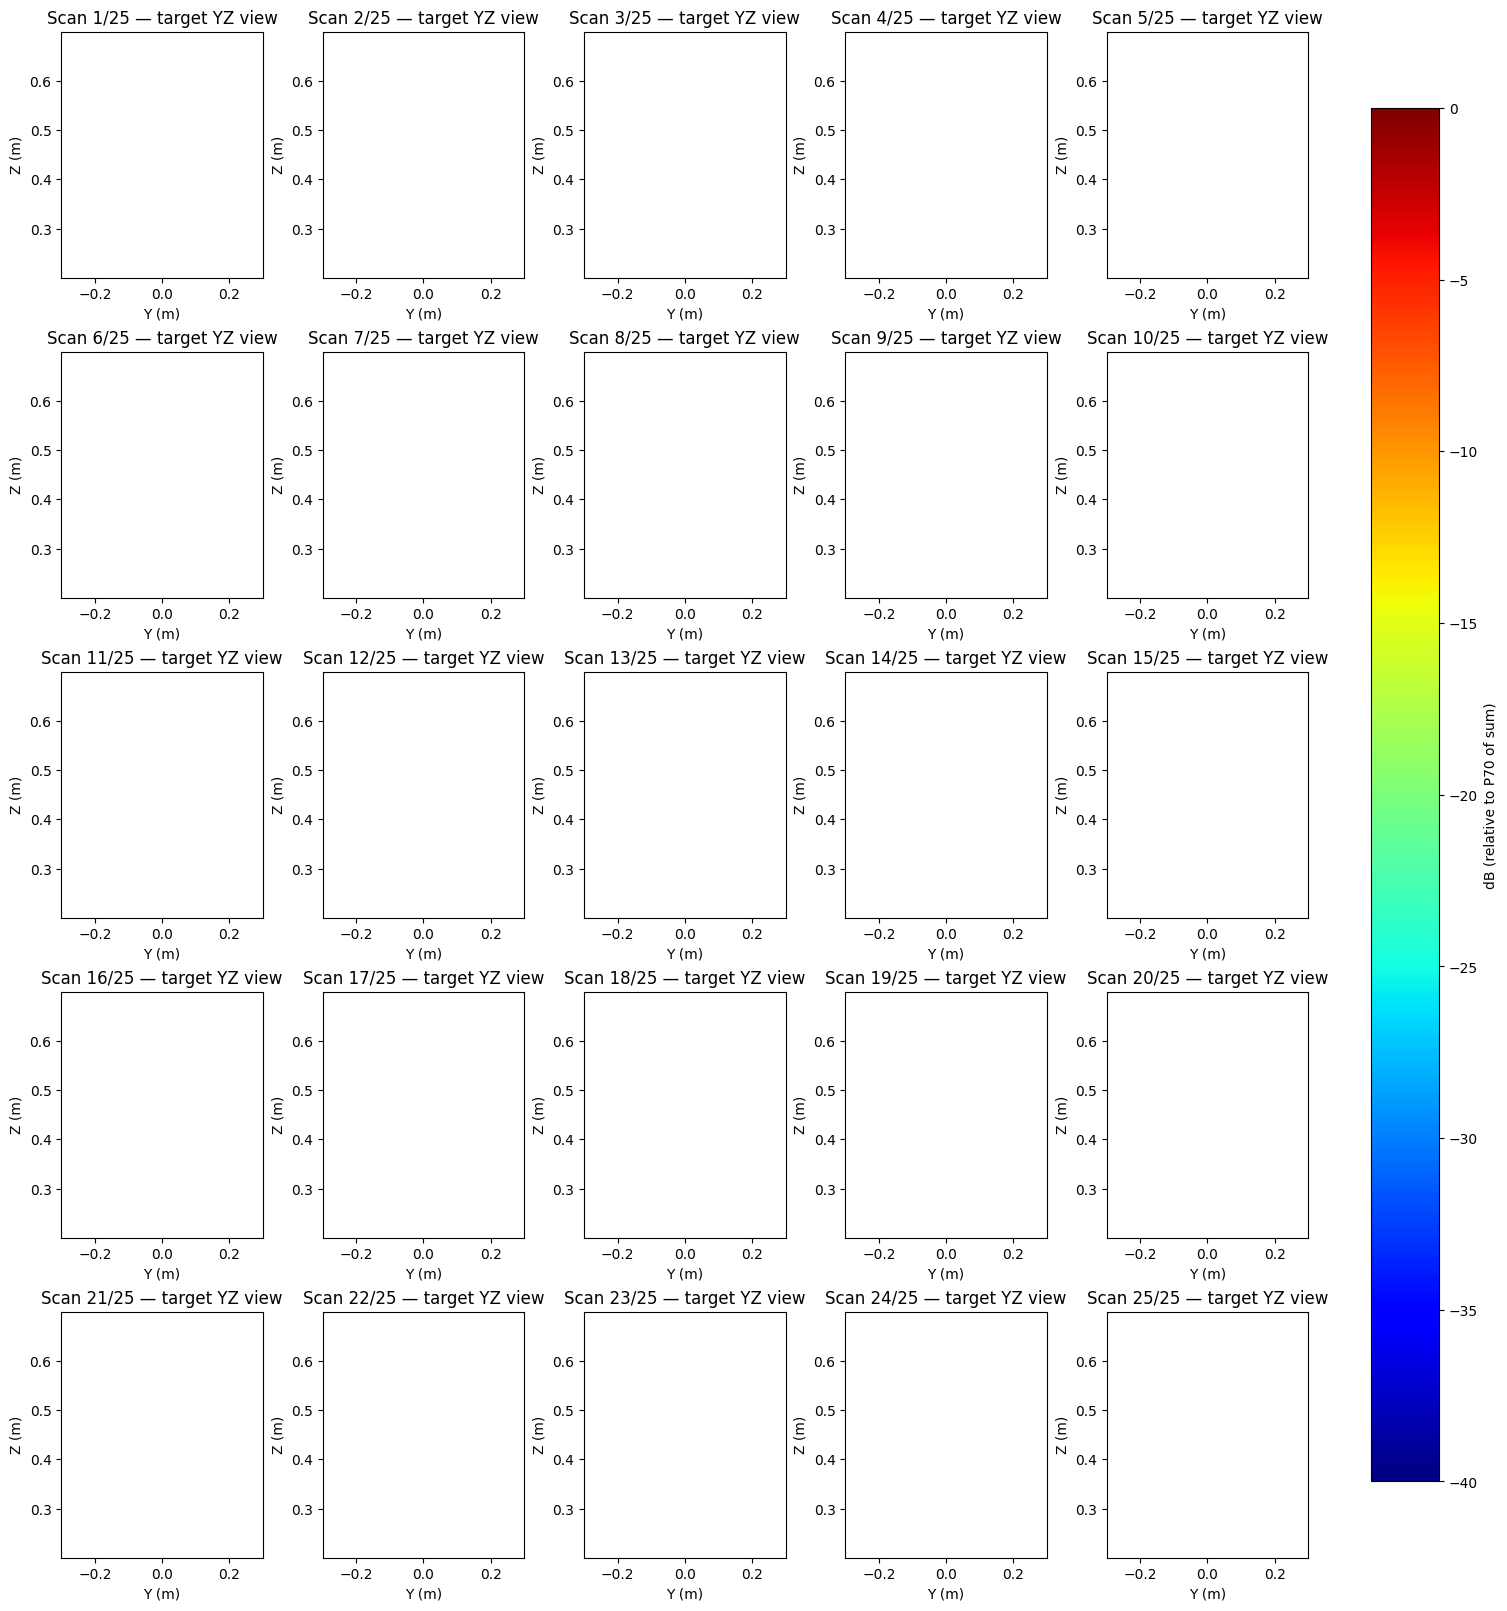

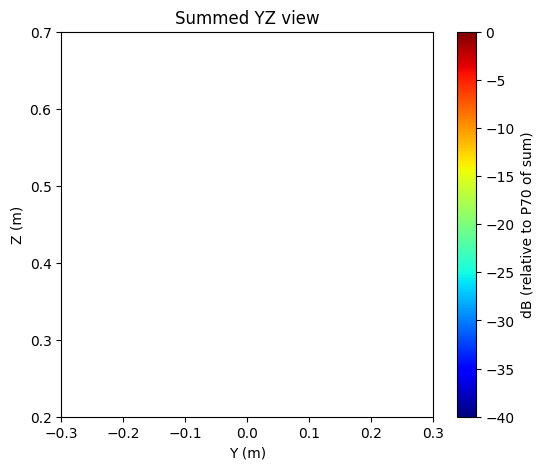

In [34]:
# quick sanity
# --- Extract axes from meta and coerce to Y(horizontal) / Z(vertical)
rows = np.asarray(meta["rows"])
cols = np.asarray(meta["cols"])
sliceName = meta.get("sliceName", "YZ")

# Determine which axis is Y and which is Z in the current image,
# then return image data so that axis-0 is Z (vertical) and axis-1 is Y (horizontal).
def yz_view(img2d, rows, cols, sliceName):
    # img2d shape: [len(rows), len(cols)]
    if sliceName == "YZ":
        # rows = Y, cols = Z  -> need transpose so vertical=Z, horizontal=Y
        return img2d.T, cols, rows   # z_axis, y_axis
    elif sliceName == "XZ":
        # rows = X, cols = Z  -> Y not present; we’ll label X as “Y” placeholder
        return img2d.T, cols, rows   # z_axis=Z, y_axis=X  (note: semantic mismatch)
    else:  # "XY"
        # rows = X, cols = Y  -> no Z; we’ll label X as “Z” placeholder
        return img2d, rows, cols     # z_axis=X, y_axis=Y  (note: semantic mismatch)

# Prepare stacks in YZ plotting orientation
R, C, N = y_stack.shape
imgs_yz = []
for i in range(N):
    img2d = y_stack[:,:,i]
    img_yz, z_axis, y_axis = yz_view(img2d, rows, cols, sliceName)
    imgs_yz.append(img_yz)
imgs_yz = np.stack(imgs_yz, axis=2)  # [Z, Y, N]

sum_yz, z_axis, y_axis = yz_view(y_sum, rows, cols, sliceName)

# --- Enforce requested bounds
# User-specified bounds:
ymin_req, ymax_req = -0.3, 0.3
zmin_req, zmax_req =  0.2, 0.7

# Clip axes to requested ranges (and find their min/max for extent)
y_mask = (y_axis >= ymin_req) & (y_axis <= ymax_req)
z_mask = (z_axis >= zmin_req) & (z_axis <= zmax_req)

# If bounds exceed available axis range, intersect with actual data
if not y_mask.any():  # fallback: use full axis
    y_mask = np.ones_like(y_axis, dtype=bool)
if not z_mask.any():
    z_mask = np.ones_like(z_axis, dtype=bool)

# Apply masks
imgs_yz = imgs_yz[z_mask][:, y_mask, :]
sum_yz  = sum_yz [z_mask][:, y_mask]
y_axis  = y_axis [y_mask]
z_axis  = z_axis [z_mask]

# Extent for imshow: [x_min, x_max, y_min, y_max] -> here x=Y, y=Z
extent = [float(y_axis.min()), float(y_axis.max()), float(z_axis.min()), float(z_axis.max())]

# --- dB scaling with fixed window
DR = 40  # dB range
ref = max(np.percentile(sum_yz, 10), 1e-12)  # robust reference (P70 of sum)
def to_db(a, ref=ref):
    a = np.maximum(a, 1e-12)
    return 20*np.log10(a / ref)

vmin, vmax = -DR, 0

# --- grid size for multiple scans
N = imgs_yz.shape[2]
ncols = int(np.ceil(np.sqrt(N)))
nrows = int(np.ceil(N/ncols))
if N == 25:
    nrows = ncols = 5

# --- plot individual scans (Y on horizontal, Z on vertical) ---
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 3.2*nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for i in range(N):
    ax = axes[i]
    im = ax.imshow(to_db(imgs_yz[:,:,i]), origin='lower', extent=extent, cmap='jet',
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f"Scan {i+1}/{N} — target YZ view")
    ax.set_xlabel("Y (m)")
    ax.set_ylabel("Z (m)")

for j in range(N, len(axes)):
    fig.delaxes(axes[j])

cbar = fig.colorbar(im, ax=axes[:N], shrink=0.9)
cbar.set_label("dB (relative to P70 of sum)")
plt.show()

# --- summed image (YZ view) ---
plt.figure(figsize=(6,5))
plt.imshow(to_db(sum_yz), origin='lower', extent=extent, cmap='jet',
           vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar(label="dB (relative to P70 of sum)")
plt.title("Summed YZ view")
plt.xlabel("Y (m)")
plt.ylabel("Z (m)")
plt.xlim(ymin_req, ymax_req)
plt.ylim(zmin_req, zmax_req)
plt.show()

In [ ]:
#Optional save data

In [ ]:
data_path = os.path.join(save_dir, f"BackprojectionData_YZ_{timestamp}.npz")
np.savez(data_path, imgs_yz=imgs_yz, sum_yz=sum_yz, y_axis=y_axis, z_axis=z_axis,
         y_stack_original=y_stack, y_sum_original=y_sum, meta=meta)

print(f"Saved:\n- Grid plot: {grid_plot_path}\n- Summed plot: {sum_plot_path}\n- Data: {data_path}")